In [1]:
import os
from tqdm import tqdm
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from collections import Counter
from PIL import Image
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns



In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


In [3]:
def setSeed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

setSeed()

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:

data_dir = '/content/drive/MyDrive/The IQ-OTHNCCD lung cancer dataset'


In [6]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

data_dir = '/content/drive/MyDrive/The IQ-OTHNCCD lung cancer dataset'
dataset = datasets.ImageFolder(root=data_dir, transform=transform)

print(f'Classes: {dataset.classes}')
print(f'Total images: {len(dataset)}')

Classes: ['Bengin cases', 'Malignant cases', 'Normal cases']
Total images: 1097


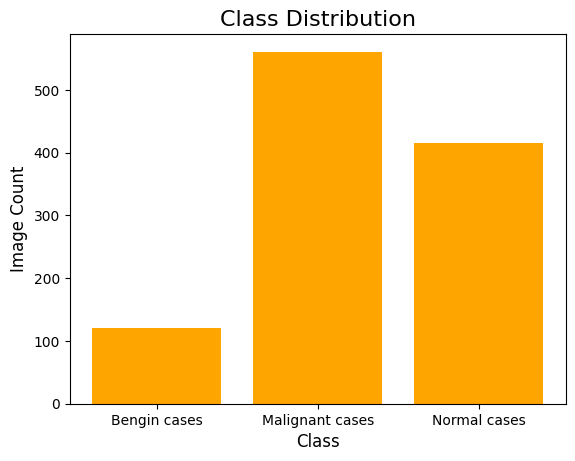

Bengin cases : 120
Malignant cases : 561
Normal cases : 416


In [7]:
class_counts = Counter([label for _, label in dataset.samples])
classes = list(dataset.classes)
counts = [class_counts[i] for i in range(len(classes))]

plt.bar(classes, counts, color='orange')

plt.title('Class Distribution', fontsize=16)
plt.xlabel('Class', fontsize=12)
plt.ylabel('Image Count', fontsize=12)
plt.show()

for cls, cnt in zip(classes, counts):
    print(f"{cls:10s} : {cnt}")

In [8]:
dataset = datasets.ImageFolder(root=data_dir, transform=transform)

train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_ds, val_ds, test_ds = random_split(dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

print(f'Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}')

Train: 767, Val: 164, Test: 166


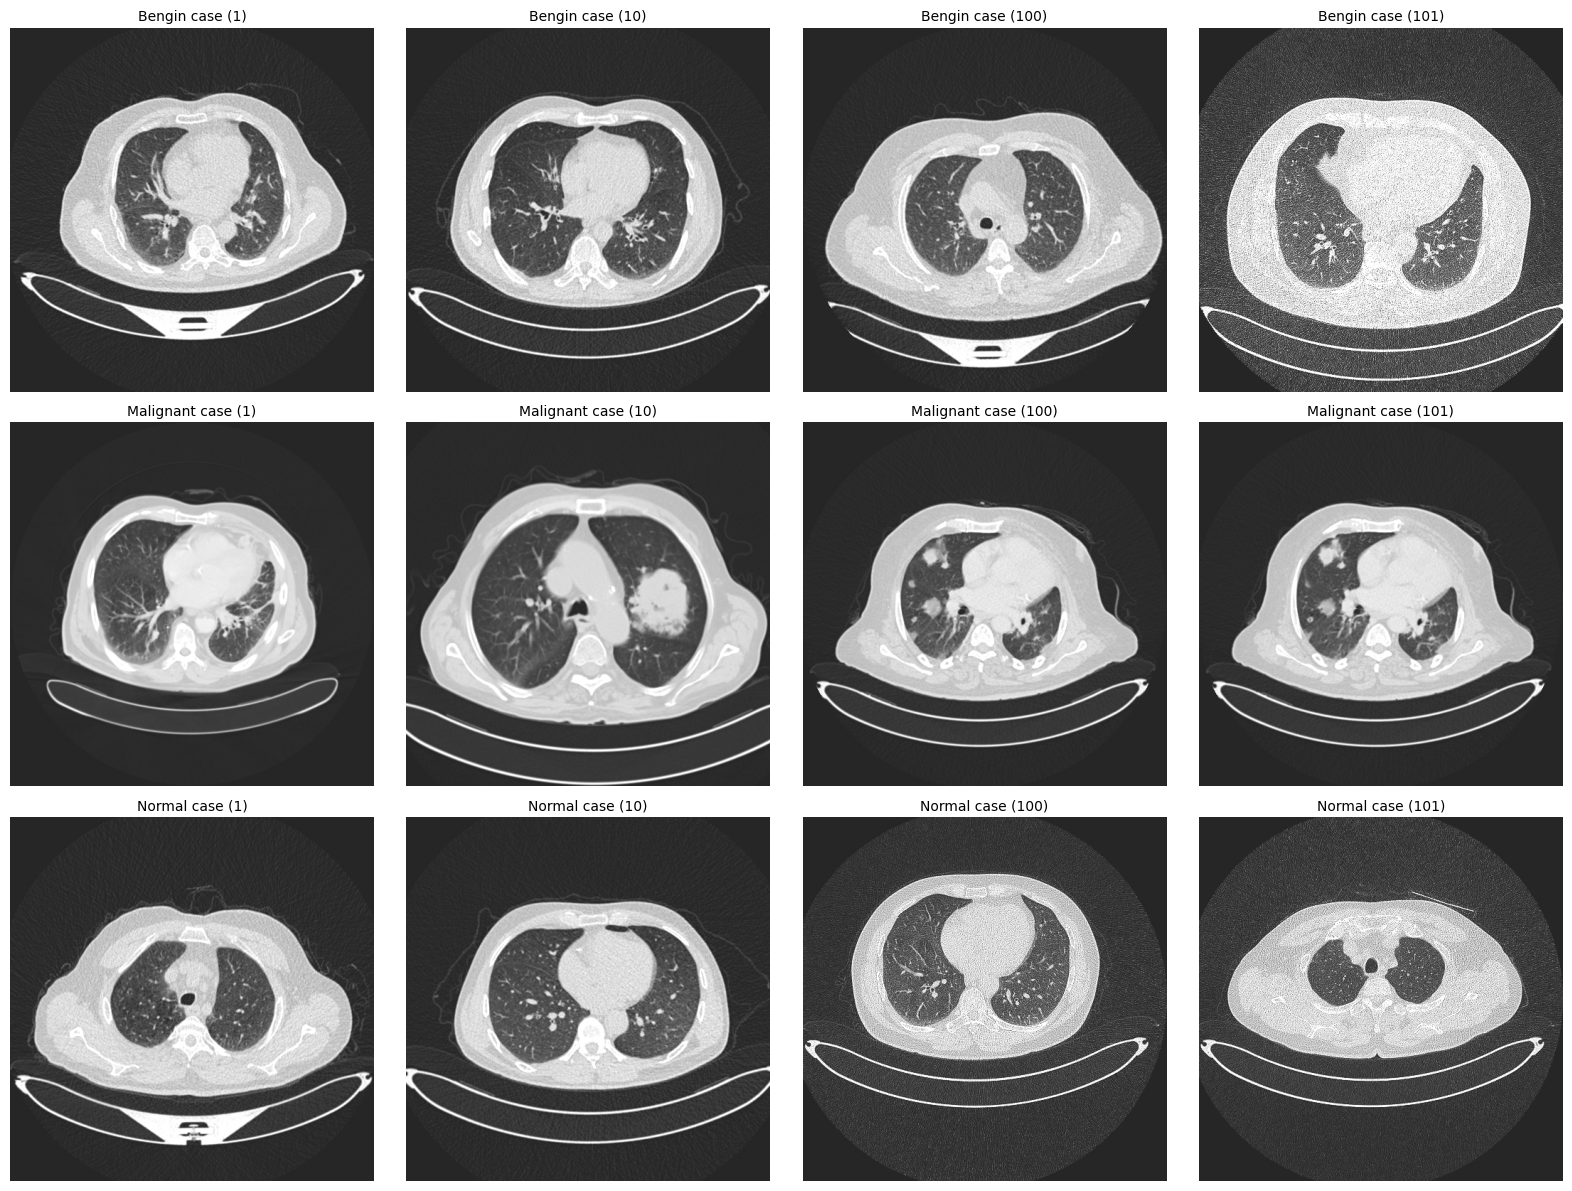

In [9]:
n_per_class = 4

samples = dataset.samples
classes = dataset.classes

fig, axes = plt.subplots(len(classes), n_per_class, figsize=(n_per_class * 4, len(classes) * 4))

for i, cls in enumerate(classes):
    cls_imgs = [path for path, label in samples if label == i][:n_per_class]

    for j, path in enumerate(cls_imgs):
        img = Image.open(path)
        axes[i, j].imshow(img)
        axes[i, j].axis('off')

        label = os.path.splitext(os.path.basename(path))[0]
        axes[i, j].set_title(label, fontsize=10, pad=5)

        if j == 0:
            axes[i, j].set_ylabel(cls, rotation=0, labelpad=30, fontsize=14, weight='bold')

plt.tight_layout()
plt.show()

In [10]:
class LungCNN(nn.Module):
    def __init__(self, num_classes=3):
        super(LungCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.AdaptiveAvgPool2d((6, 6))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 6 * 6, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = LungCNN(num_classes=3).to(device)
print(model)

LungCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): AdaptiveAvgPool2d(output_size=(6, 6))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2304, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=3, bias=True)
  )
)


In [11]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [13]:
num_epochs = 50
best_val_acc = 0.0
best_val_loss = np.inf
best_model_wts = copy.deepcopy(model.state_dict())

os.makedirs('checkpoints', exist_ok=True)
save_path = 'checkpoints/model.pth'

train_losses, val_losses, val_accuracies = [], [], []

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print("-" * 40)

    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in tqdm(train_loader, desc='Training', leave=False):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct_train / total_train

    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc='Validation', leave=True):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_loss /= len(val_loader)
    val_acc = 100 * correct_val / total_val

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%')
    print(f'Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.2f}%')

    if val_loss < best_val_loss:
        best_val_acc = val_acc
        best_val_loss = val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(best_model_wts, save_path)
        print(f'Best model updated and saved (Val Loss: {val_loss:.2f})')

print("\nTraining complete")
print(f'Best Validation Accuracy (with minimal loss): {best_val_acc:.2f}%')

model.load_state_dict(best_model_wts)
print('Restored best model weights')



Epoch 1/50
----------------------------------------


Validation: 100%|██████████| 6/6 [00:40<00:00,  6.82s/it]


Train Loss: 0.9631 | Train Acc: 47.85%
Val   Loss: 0.9535 | Val   Acc: 52.44%
Best model updated and saved (Val Loss: 0.95)

Epoch 2/50
----------------------------------------


Validation: 100%|██████████| 6/6 [00:04<00:00,  1.35it/s]


Train Loss: 0.9249 | Train Acc: 51.24%
Val   Loss: 0.9232 | Val   Acc: 62.80%
Best model updated and saved (Val Loss: 0.92)

Epoch 3/50
----------------------------------------


...

Train Loss: 0.1466 | Train Acc: 95.31%
Val   Loss: 0.2532 | Val   Acc: 92.07%

Epoch 49/50
----------------------------------------


Validation: 100%|██████████| 6/6 [00:03<00:00,  1.67it/s]


Train Loss: 0.1337 | Train Acc: 95.83%
Val   Loss: 0.2178 | Val   Acc: 90.85%

Epoch 50/50
----------------------------------------


Validation: 100%|██████████| 6/6 [00:03<00:00,  1.68it/s]

Train Loss: 0.1348 | Train Acc: 95.96%
Val   Loss: 0.2456 | Val   Acc: 92.68%

Training complete
Best Validation Accuracy (with minimal loss): 91.46%
Restored best model weights


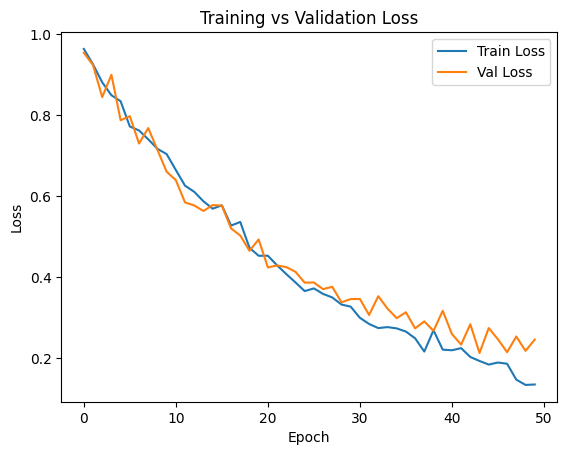

In [14]:
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

In [18]:
y_true = []
y_pred = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

In [19]:
from sklearn.metrics import cohen_kappa_score
kappa = cohen_kappa_score(y_true, y_pred)

print(f"Cohen's Kappa Score: {kappa:.4f}")


Cohen's Kappa Score: 0.9167


In [21]:
from sklearn.model_selection import train_test_split
import numpy as np

X = []
y = []

for images, labels in train_loader:

    for i in range(images.size(0)):

        img = images[i].numpy().flatten()

        X.append(img)
        y.append(labels[i].item())

X = np.array(X)
y = np.array(y)

X_train, X_test, y_train_ml, y_test_ml = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Feature Extraction Completed")
print("X_train shape:", X_train.shape)

Feature Extraction Completed
X_train shape: (613, 49152)


In [22]:

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train_ml)

lr_pred = lr_model.predict(X_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test_ml, lr_pred))

Logistic Regression Accuracy: 0.9805194805194806


In [24]:
from sklearn.model_selection import train_test_split
import numpy as np

X = []
y = []

for images, labels in train_loader:

    for i in range(images.size(0)):

        img = images[i].numpy().flatten()

        X.append(img)
        y.append(labels[i].item())

X = np.array(X)
y = np.array(y)

X_train, X_test, y_train_ml, y_test_ml = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Dataset Ready")
print(X_train.shape)

Dataset Ready
(613, 49152)


In [25]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train_ml)

dt_pred = dt_model.predict(X_test)

print("Decision Tree Accuracy:",
      accuracy_score(y_test_ml, dt_pred))

Decision Tree Accuracy: 0.8116883116883117


In [26]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train_ml)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test_ml, rf_pred))

Random Forest Accuracy: 0.9155844155844156


In [27]:
from sklearn.svm import SVC

svm_model = SVC(kernel='linear')

svm_model.fit(X_train, y_train_ml)

svm_pred = svm_model.predict(X_test)

print("SVM Accuracy:",
      accuracy_score(y_test_ml, svm_pred))

SVM Accuracy: 0.987012987012987


In [30]:
print("LR Kappa Score:",
      cohen_kappa_score(y_test_ml, lr_pred))
print("RF Kappa Score:",
      cohen_kappa_score(y_test_ml, rf_pred))
print("SVM Kappa Score:",
      cohen_kappa_score(y_test_ml, svm_pred))

LR Kappa Score: -0.033409480296973326
RF Kappa Score: 0.8545586632764257
SVM Kappa Score: 0.978240904274108


                 precision    recall  f1-score   support

   Bengin cases       0.78      0.82      0.80        17
Malignant cases       0.99      0.99      0.99        86
   Normal cases       0.95      0.94      0.94        63

       accuracy                           0.95       166
      macro avg       0.91      0.92      0.91       166
   weighted avg       0.95      0.95      0.95       166



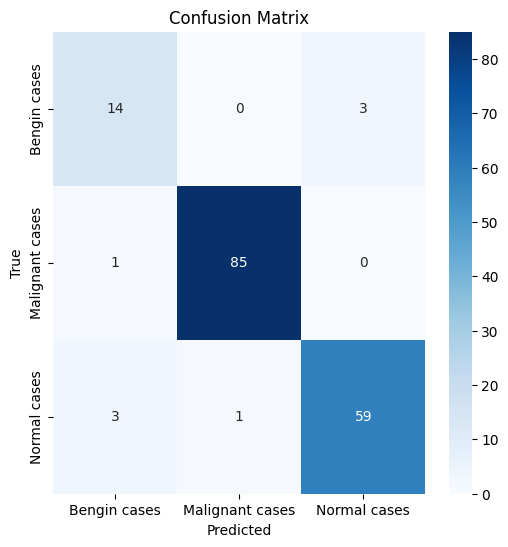

In [31]:
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

print(classification_report(y_true, y_pred, target_names=dataset.classes))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=dataset.classes,
            yticklabels=dataset.classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()